In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
from PIL import Image
from IPython import display

In [2]:
def as_gif(images, path="temp.gif", dur=4):
  # Render the images as the gif (15Hz control frequency):
  images[0].save(path, save_all=True, append_images=images[1:], duration=int(1000/dur), loop=0)
  gif_bytes = open(path,"rb").read()
  return gif_bytes

In [4]:
from pathlib import Path

data_dir = Path("data")
builder = tfds.builder_from_directory(str(data_dir))

In [5]:
ds = builder.as_dataset(split="train")

In [48]:
iterator = iter(ds)

In [61]:
episode = next(iterator)

In [62]:
episode.keys()

dict_keys(['steps', 'success'])

In [63]:
episode['success']

<tf.Tensor: shape=(), dtype=bool, numpy=True>

In [64]:
episodes = list(episode['steps'])

In [65]:
len(episodes)

10

In [66]:
episodes[0].keys()

dict_keys(['action', 'is_first', 'is_last', 'is_terminal', 'observation', 'reward'])

In [67]:
episodes[0]['action'].keys()

dict_keys(['base_displacement_vector', 'base_displacement_vertical_rotation', 'gripper_closedness_action', 'rotation_delta', 'terminate_episode', 'world_vector'])

In [68]:
episodes[0]['observation'].keys()

dict_keys(['clip_function_input/base_pose_tool_reached', 'clip_function_input/workspace_bounds', 'gripper_closed', 'height_to_bottom', 'image', 'natural_language_embedding', 'natural_language_instruction', 'task_id'])

In [72]:
episodes[0]['action']['world_vector']

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([-0.01358562,  0.03647279, -0.07325599], dtype=float32)>

In [74]:
episodes[0]['observation']['clip_function_input/base_pose_tool_reached'][:3]

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([0.49838024, 0.05143018, 0.143256  ], dtype=float32)>

In [75]:
episodes[1]['observation']['clip_function_input/base_pose_tool_reached'][:3] - episodes[0]['observation']['clip_function_input/base_pose_tool_reached'][:3]

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([ 0.00199425, -0.00014146,  0.00329612], dtype=float32)>

In [88]:
episodes[1]['observation']['clip_function_input/base_pose_tool_reached'][:3] - episodes[0]['action']['world_vector'] - episodes[0]['observation']['clip_function_input/base_pose_tool_reached'][:3]

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([ 0.01557988, -0.03661424,  0.07655211], dtype=float32)>

In [69]:
images = []
for i, step in enumerate(episode["steps"]):
    if i % 1 == 0:

        images.append(
            Image.fromarray(
            np.concatenate((
                    step["observation"]["image"].numpy(),
            ), axis=1)
            )
        )

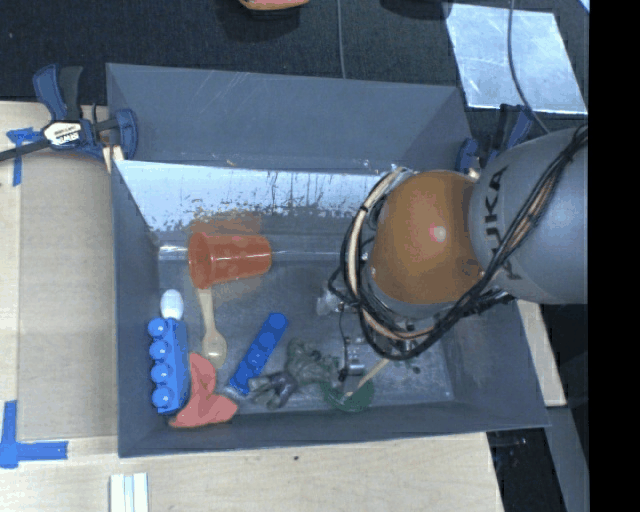

In [70]:
display.Image(as_gif(images, dur=8))

In [71]:
episodes[0]['observation']['natural_language_instruction']

<tf.Tensor: shape=(), dtype=string, numpy=b'pick anything'>

local shard count: 1
  data\kuka-train.tfrecord-00000-of-01024

world_vector shape: (8764, 3)
min : [-0.12488155 -0.32942098 -0.18867871]
max : [0.12787795 0.37326464 0.2979764 ]
mean: [-0.00046603  0.00045957 -0.00272933]
std : [0.02353914 0.03875914 0.05928314]

rotation_delta shape: (8764, 3)
min : [ 0.         0.        -1.4233651]
max : [0.        0.        0.9713977]
mean: [ 0.          0.         -0.03911136]
std : [0.         0.         0.16012451]

episode count: 580
min   : 3
max   : 24
mean  : 15.110344827586207
median: 15.0
p_05  : 6.0
p_95  : 21.0


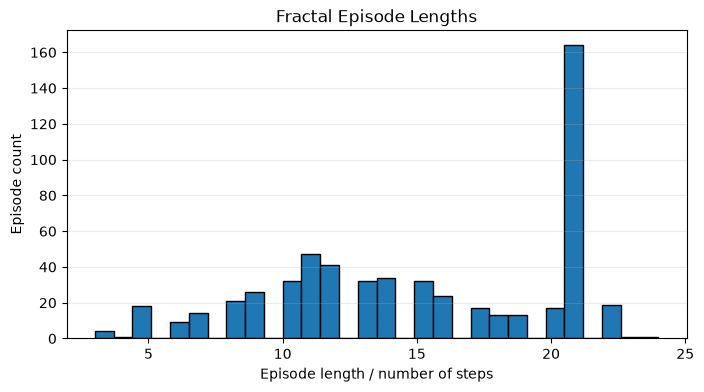

In [24]:
import matplotlib.pyplot as plt
import glob

local_tfrecords = sorted(glob.glob("data/kuka-train.tfrecord*"))
print("local shard count:", len(local_tfrecords))
for path in local_tfrecords:
    print(" ", path)

local_ds = tf.data.TFRecordDataset(local_tfrecords).map(
    builder.info.features.deserialize_example,
    num_parallel_calls=tf.data.AUTOTUNE,
)

world_vectors = []
rotation_deltas = []
episode_lengths = []

for episode_index, episode in enumerate(local_ds):
    steps = list(episode["steps"])
    episode_lengths.append(len(steps))

    for step in steps:
        world_vectors.append(step["action"]["world_vector"].numpy())
        rotation_deltas.append(step["action"]["rotation_delta"].numpy())

world_vectors = np.stack(world_vectors, axis=0)
rotation_deltas = np.stack(rotation_deltas, axis=0)
episode_lengths = np.asarray(episode_lengths, dtype=np.int64)

def print_vector_stats(name, values):
    print(f"\n{name} shape: {values.shape}")
    print("min :", values.min(axis=0))
    print("max :", values.max(axis=0))
    print("mean:", values.mean(axis=0))
    print("std :", values.std(axis=0))

def print_length_stats(lengths):
    print(f"\nepisode count: {len(lengths)}")
    print("min   :", lengths.min())
    print("max   :", lengths.max())
    print("mean  :", lengths.mean())
    print("median:", np.median(lengths))
    print("p_05  :", np.percentile(lengths, 5))
    print("p_95  :", np.percentile(lengths, 95))

print_vector_stats("world_vector", world_vectors)
print_vector_stats("rotation_delta", rotation_deltas)
print_length_stats(episode_lengths)

plt.figure(figsize=(8, 4))
plt.hist(episode_lengths, bins=30, edgecolor="black")
plt.title("Kuka Episode Lengths")
plt.xlabel("Episode length / number of steps")
plt.ylabel("Episode count")
plt.grid(axis="y", alpha=0.25)
plt.show()

In [91]:
# Check whether quaternion-derived RPY deltas line up with rotation_delta in radians or degrees.
# Assumes base_pose_tool_reached = [x, y, z, qx, qy, qz, qw].

def quat_xyzw_to_rpy_rad(quat_xyzw):
    q = np.asarray(quat_xyzw, dtype=np.float64)
    x, y, z, w = q[..., 0], q[..., 1], q[..., 2], q[..., 3]

    roll = np.arctan2(2.0 * (w * x + y * z), 1.0 - 2.0 * (x * x + y * y))
    sin_pitch = 2.0 * (w * y - z * x)
    pitch = np.where(np.abs(sin_pitch) >= 1.0, np.sign(sin_pitch) * np.pi / 2.0, np.arcsin(sin_pitch))
    yaw = np.arctan2(2.0 * (w * z + x * y), 1.0 - 2.0 * (y * y + z * z))

    return np.stack([roll, pitch, yaw], axis=-1).astype(np.float32)


def wrap_angle_delta_rad(delta):
    return (delta + np.pi) % (2.0 * np.pi) - np.pi


if "local_ds" not in globals():
    local_tfrecords = sorted(glob.glob("data/kuka-train.tfrecord*"))
    local_ds = tf.data.TFRecordDataset(local_tfrecords).map(
        builder.info.features.deserialize_example,
        num_parallel_calls=tf.data.AUTOTUNE,
    )

all_rotation_actions = []
all_rpy_delta_rad = []
all_rpy_delta_deg = []
all_rpy_rad = []
all_rpy_deg = []

for episode in local_ds:
    steps = list(episode["steps"])
    if len(steps) < 2:
        continue

    poses = np.stack([
        step["observation"]["clip_function_input/base_pose_tool_reached"].numpy()
        for step in steps
    ], axis=0)
    rotation_actions = np.stack([
        step["action"]["rotation_delta"].numpy()
        for step in steps
    ], axis=0)

    rpy_rad = quat_xyzw_to_rpy_rad(poses[:, 3:7])
    rpy_delta_rad = wrap_angle_delta_rad(rpy_rad[1:] - rpy_rad[:-1])

    all_rotation_actions.append(rotation_actions[:-1])
    all_rpy_delta_rad.append(rpy_delta_rad)
    all_rpy_delta_deg.append(np.rad2deg(rpy_delta_rad))
    all_rpy_rad.append(rpy_rad)
    all_rpy_deg.append(np.rad2deg(rpy_rad))

rotation_actions = np.concatenate(all_rotation_actions, axis=0)
rpy_delta_rad = np.concatenate(all_rpy_delta_rad, axis=0)
rpy_delta_deg = np.concatenate(all_rpy_delta_deg, axis=0)
rpy_rad = np.concatenate(all_rpy_rad, axis=0)
rpy_deg = np.concatenate(all_rpy_deg, axis=0)

def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2, axis=0))


print("RPY radians range:")
print("min:", rpy_rad.min(axis=0))
print("max:", rpy_rad.max(axis=0))
print("\nRPY degrees range:")
print("min:", rpy_deg.min(axis=0))
print("max:", rpy_deg.max(axis=0))

print("\nrotation_delta action range:")
print("min:", rotation_actions.min(axis=0))
print("max:", rotation_actions.max(axis=0))
print("mean:", rotation_actions.mean(axis=0))
print("std:", rotation_actions.std(axis=0))

print("\nRMSE action vs observed RPY delta, radians:", rmse(rotation_actions, rpy_delta_rad))
print("RMSE action vs observed RPY delta, degrees :", rmse(rotation_actions, rpy_delta_deg))

for i, axis in enumerate(["roll", "pitch", "yaw"]):
    corr_rad = np.corrcoef(rotation_actions[:, i], rpy_delta_rad[:, i])[0, 1]
    corr_deg = np.corrcoef(rotation_actions[:, i], rpy_delta_deg[:, i])[0, 1]
    scale_rad = np.linalg.lstsq(rotation_actions[:, [i]], rpy_delta_rad[:, i], rcond=None)[0][0]
    scale_deg = np.linalg.lstsq(rotation_actions[:, [i]], rpy_delta_deg[:, i], rcond=None)[0][0]
    print(f"\n{axis}")
    print("  corr action vs observed delta rad:", corr_rad)
    print("  corr action vs observed delta deg:", corr_deg)
    print("  scale observed_delta_rad ~= scale * action:", scale_rad)
    print("  scale observed_delta_deg ~= scale * action:", scale_deg)

print("\nRecommendation: use radians for standardized RPY. Degrees are only for display/debugging.")

RPY radians range:
min: [-3.1415925  -0.09140755 -3.1415925 ]
max: [3.1415925  0.19418246 3.141557  ]

RPY degrees range:
min: [-179.99998     -5.2372665 -179.99998  ]
max: [179.99998   11.125834 179.99794 ]

rotation_delta action range:
min: [ 0.         0.        -1.4233651]
max: [0.        0.        0.9713977]
mean: [ 0.          0.         -0.04188318]
std: [0.         0.         0.16535224]

RMSE action vs observed RPY delta, radians: [0.00467851 0.0085472  0.26381192]
RMSE action vs observed RPY delta, degrees : [0.26805896 0.4897175  8.1437435 ]

roll
  corr action vs observed delta rad: nan
  corr action vs observed delta deg: nan
  scale observed_delta_rad ~= scale * action: 0.0
  scale observed_delta_deg ~= scale * action: 0.0

pitch
  corr action vs observed delta rad: nan
  corr action vs observed delta deg: nan
  scale observed_delta_rad ~= scale * action: 0.0
  scale observed_delta_deg ~= scale * action: 0.0

yaw
  corr action vs observed delta rad: -0.40439438176780557
 

c:\Users\rshre\thinkflow_rdt1b_lora\.venv\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\rshre\thinkflow_rdt1b_lora\.venv\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [92]:
import glob

episodes checked: 580

action/gripper_closedness_action
  min/max/mean/std: -1.0 1.0 0.06846189 0.38230526
  most common rounded values:
     0.000: 7442
     1.000: 961
    -1.000: 361

observation/gripper_closed
  min/max/mean/std: 0.0 1.0 0.372775 0.48354298
  most common rounded values:
     0.000: 5497
     1.000: 3267

Relationship tests, lower RMSE / higher corr is more plausible:
  action[t] vs closed[t]       RMSE/corr: 0.7174851298332214 -0.14689451787354726
  action[t] vs closed[t+1]     RMSE/corr: 0.5708587765693665 0.45553037965835846
  action[t] vs closed delta    RMSE/corr: 0.20502008497714996 0.8569465714002911
  -action[t] vs closed[t+1]    RMSE/corr: 0.8919510841369629 -0.45553037965835846
  action sign counts:
    positive action >  0.05: 961
    negative action < -0.05: 361
    no-op-ish |action|<=0.05: 7442

First episodes with gripper activity:

episode 0 window 0:9, center=5
 step | action | closed | d_closed
    0 |   0.000 |  0.000 |      nan
    1 |   0.000 | 

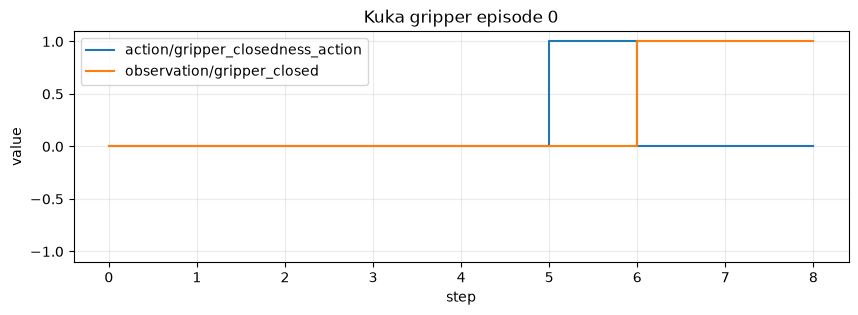

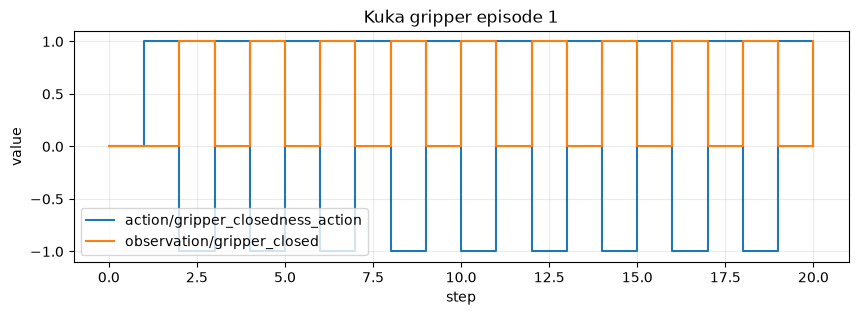

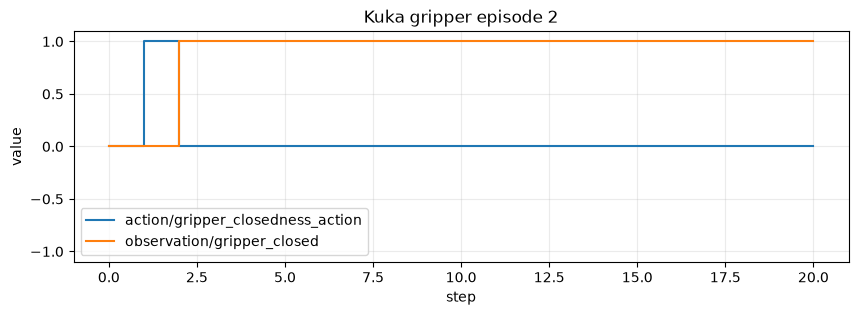

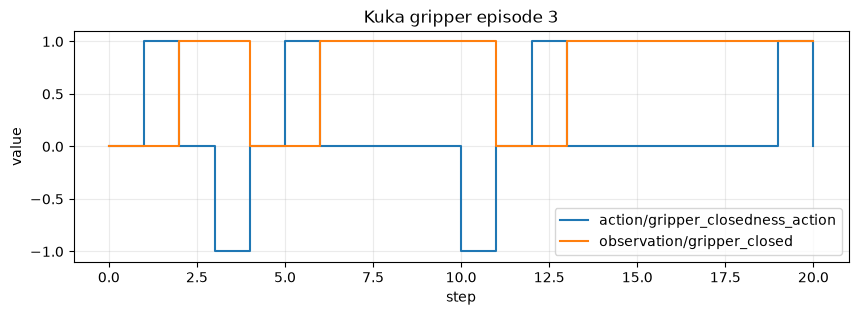

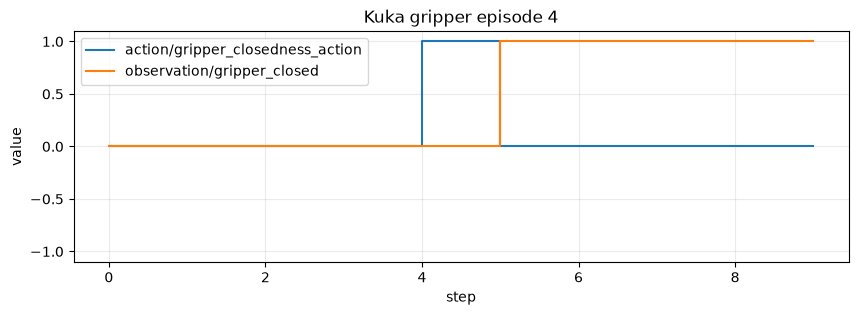


Interpretation hint:
  observation/gripper_closed is the measured gripper state candidate.
  action/gripper_closedness_action may be a command or target; use windows above to infer sign/hold behavior.


In [95]:
# Kuka gripper convention audit.
# Kuka has action/gripper_closedness_action and observation/gripper_closed,
# but no observation/gripper_closedness_commanded field.

if "local_ds" not in globals():
    local_tfrecords = sorted(glob.glob("data/kuka-train.tfrecord*"))
    print("local shard count:", len(local_tfrecords))
    local_ds = tf.data.TFRecordDataset(local_tfrecords).map(
        builder.info.features.deserialize_example,
        num_parallel_calls=tf.data.AUTOTUNE,
    )

gripper_episodes = []

for episode_index, episode in enumerate(local_ds):
    steps = list(episode["steps"])
    if len(steps) == 0:
        continue

    action = np.asarray([
        step["action"]["gripper_closedness_action"].numpy().reshape(-1)[0]
        for step in steps
    ], dtype=np.float32)
    closed = np.asarray([
        step["observation"]["gripper_closed"].numpy().reshape(-1)[0]
        for step in steps
    ], dtype=np.float32)

    gripper_episodes.append({
        "episode_index": episode_index,
        "action": action,
        "closed": closed,
    })

all_action = np.concatenate([ep["action"] for ep in gripper_episodes])
all_closed = np.concatenate([ep["closed"] for ep in gripper_episodes])

def print_scalar_stats(name, values):
    rounded = np.round(values, 3)
    unique, counts = np.unique(rounded, return_counts=True)
    order = np.argsort(counts)[::-1]
    print(f"\n{name}")
    print("  min/max/mean/std:", values.min(), values.max(), values.mean(), values.std())
    print("  most common rounded values:")
    for idx in order[:12]:
        print(f"    {unique[idx]: .3f}: {counts[idx]}")

def rmse_1d(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def corr_1d(a, b):
    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

action_current = []
closed_current = []
closed_next = []
closed_delta = []

for ep in gripper_episodes:
    if len(ep["action"]) < 2:
        continue
    action_current.append(ep["action"][:-1])
    closed_current.append(ep["closed"][:-1])
    closed_next.append(ep["closed"][1:])
    closed_delta.append(ep["closed"][1:] - ep["closed"][:-1])

action_current = np.concatenate(action_current)
closed_current = np.concatenate(closed_current)
closed_next = np.concatenate(closed_next)
closed_delta = np.concatenate(closed_delta)

print("episodes checked:", len(gripper_episodes))
print_scalar_stats("action/gripper_closedness_action", all_action)
print_scalar_stats("observation/gripper_closed", all_closed)

print("\nRelationship tests, lower RMSE / higher corr is more plausible:")
print("  action[t] vs closed[t]       RMSE/corr:", rmse_1d(action_current, closed_current), corr_1d(action_current, closed_current))
print("  action[t] vs closed[t+1]     RMSE/corr:", rmse_1d(action_current, closed_next), corr_1d(action_current, closed_next))
print("  action[t] vs closed delta    RMSE/corr:", rmse_1d(action_current, closed_delta), corr_1d(action_current, closed_delta))
print("  -action[t] vs closed[t+1]    RMSE/corr:", rmse_1d(-action_current, closed_next), corr_1d(-action_current, closed_next))
print("  action sign counts:")
print("    positive action >  0.05:", int(np.sum(all_action > 0.05)))
print("    negative action < -0.05:", int(np.sum(all_action < -0.05)))
print("    no-op-ish |action|<=0.05:", int(np.sum(np.abs(all_action) <= 0.05)))

def transition_indices(values, threshold=0.05):
    if len(values) < 2:
        return np.asarray([], dtype=np.int64)
    return np.where(np.abs(np.diff(values)) > threshold)[0] + 1

def nonzero_indices(values, threshold=0.05):
    return np.where(np.abs(values) > threshold)[0]

def print_gripper_window(ep, center, radius=6):
    start = max(0, center - radius)
    end = min(len(ep["action"]), center + radius + 1)
    print(f"\nepisode {ep['episode_index']} window {start}:{end}, center={center}")
    print(" step | action | closed | d_closed")
    for t in range(start, end):
        d_closed = np.nan if t == 0 else ep["closed"][t] - ep["closed"][t - 1]
        print(f" {t:4d} | {ep['action'][t]: 7.3f} | {ep['closed'][t]: 6.3f} | {d_closed:8.3f}")

print("\nFirst episodes with gripper activity:")
shown = 0
for ep in gripper_episodes:
    candidate_events = np.unique(np.concatenate([
        nonzero_indices(ep["action"], threshold=0.05),
        transition_indices(ep["closed"], threshold=0.05),
    ]))
    if len(candidate_events) == 0:
        continue
    print_gripper_window(ep, int(candidate_events[0]))
    shown += 1
    if shown >= 8:
        break

plot_eps = []
for ep in gripper_episodes:
    if len(nonzero_indices(ep["action"], threshold=0.05)) > 0 or len(transition_indices(ep["closed"], threshold=0.05)) > 0:
        plot_eps.append(ep)
    if len(plot_eps) >= 5:
        break

for ep in plot_eps:
    t = np.arange(len(ep["action"]))
    plt.figure(figsize=(10, 3))
    plt.step(t, ep["action"], where="post", label="action/gripper_closedness_action")
    plt.step(t, ep["closed"], where="post", label="observation/gripper_closed")
    plt.title(f"Kuka gripper episode {ep['episode_index']}")
    plt.xlabel("step")
    plt.ylabel("value")
    plt.ylim(-1.1, 1.1)
    plt.grid(alpha=0.25)
    plt.legend(loc="best")
    plt.show()

print("\nInterpretation hint:")
print("  observation/gripper_closed is the measured gripper state candidate.")
print("  action/gripper_closedness_action may be a command or target; use windows above to infer sign/hold behavior.")

In [94]:
import matplotlib.pyplot as plt